In [1]:
import pandas as pd 
import numpy as  np


In [19]:
df = pd.read_csv("C:/Users/My/Desktop/bank-additional-full.csv",sep=';')

In [21]:
df

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,...,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [23]:
df['education'].unique()

array(['basic.4y', 'high.school', 'basic.6y', 'basic.9y',
       'professional.course', 'unknown', 'university.degree',
       'illiterate'], dtype=object)

In [25]:
education_map = {
    'illiterate'        : 'illiterate',
    'basic.4y'          : 'literate',
    'basic.6y'          : 'literate',
    'basic.9y'          : 'literate',
    'high.school'       : 'literate',
    'professional.course': 'literate',
    'university.degree' : 'literate',
    'unknown'           : 'unknown'   
}

df['education'] = df['education'].map(education_map)

# Verify
df['education'].value_counts()

education
literate      39439
unknown        1731
illiterate       18
Name: count, dtype: int64

In [29]:
features = [
    'age', 'job', 'education', 'poutcome',
    'emp.var.rate', 'cons.price.idx', 'cons.conf.idx',
    'euribor3m', 'nr.employed', 'pdays', 'previous'
]

X = df[features]
y = df['y']

In [33]:
X

,age,job,education,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,pdays,previous
0,56,housemaid,literate,nonexistent,1.1,93.994,-36.4,4.857,5191.0,999,0
1,57,services,literate,nonexistent,1.1,93.994,-36.4,4.857,5191.0,999,0
2,37,services,literate,nonexistent,1.1,93.994,-36.4,4.857,5191.0,999,0
3,40,admin.,literate,nonexistent,1.1,93.994,-36.4,4.857,5191.0,999,0
4,56,services,literate,nonexistent,1.1,93.994,-36.4,4.857,5191.0,999,0
...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,literate,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,999,0
41184,46,blue-collar,literate,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,999,0
41185,56,retired,literate,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,999,0
41186,44,technician,literate,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,999,0


In [39]:
df['job'].unique()

array(['housemaid', 'services', 'admin.', 'blue-collar', 'technician',
       'retired', 'management', 'unemployed', 'self-employed', 'unknown',
       'entrepreneur', 'student'], dtype=object)

In [43]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
cat_cols = ['job','education','poutcome']
for col in cat_cols:
    X[col] = le.fit_transform(X[col])

y= le.fit_transform(y)

C:\Users\My\AppData\Local\Temp\ipykernel_11192\605251770.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = le.fit_transform(X[col])
C:\Users\My\AppData\Local\Temp\ipykernel_11192\605251770.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = le.fit_transform(X[col])
C:\Users\My\AppData\Local\Temp\ipykernel_11192\605251770.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveat

In [45]:
df

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,literate,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,literate,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,literate,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,literate,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,literate,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,literate,no,yes,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41184,46,blue-collar,married,literate,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,literate,no,yes,no,cellular,nov,fri,...,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41186,44,technician,married,literate,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes


In [49]:
X

,age,job,education,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,pdays,previous
0,56,3,1,1,1.1,93.994,-36.4,4.857,5191.0,999,0
1,57,7,1,1,1.1,93.994,-36.4,4.857,5191.0,999,0
2,37,7,1,1,1.1,93.994,-36.4,4.857,5191.0,999,0
3,40,0,1,1,1.1,93.994,-36.4,4.857,5191.0,999,0
4,56,7,1,1,1.1,93.994,-36.4,4.857,5191.0,999,0
...,...,...,...,...,...,...,...,...,...,...,...
41183,73,5,1,1,-1.1,94.767,-50.8,1.028,4963.6,999,0
41184,46,1,1,1,-1.1,94.767,-50.8,1.028,4963.6,999,0
41185,56,5,1,1,-1.1,94.767,-50.8,1.028,4963.6,999,0
41186,44,9,1,1,-1.1,94.767,-50.8,1.028,4963.6,999,0


In [51]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [53]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(
    max_depth=5,        # limits overfitting
    min_samples_split=10,
    random_state=42
)

dt.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, min_samples_split=10, random_state=42)

In [55]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
y_pred = dt.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.8969410050983249

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.99      0.94      7303
           1       0.64      0.21      0.31       935

    accuracy                           0.90      8238
   macro avg       0.77      0.60      0.63      8238
weighted avg       0.88      0.90      0.87      8238


Confusion Matrix:
 [[7195  108]
 [ 741  194]]


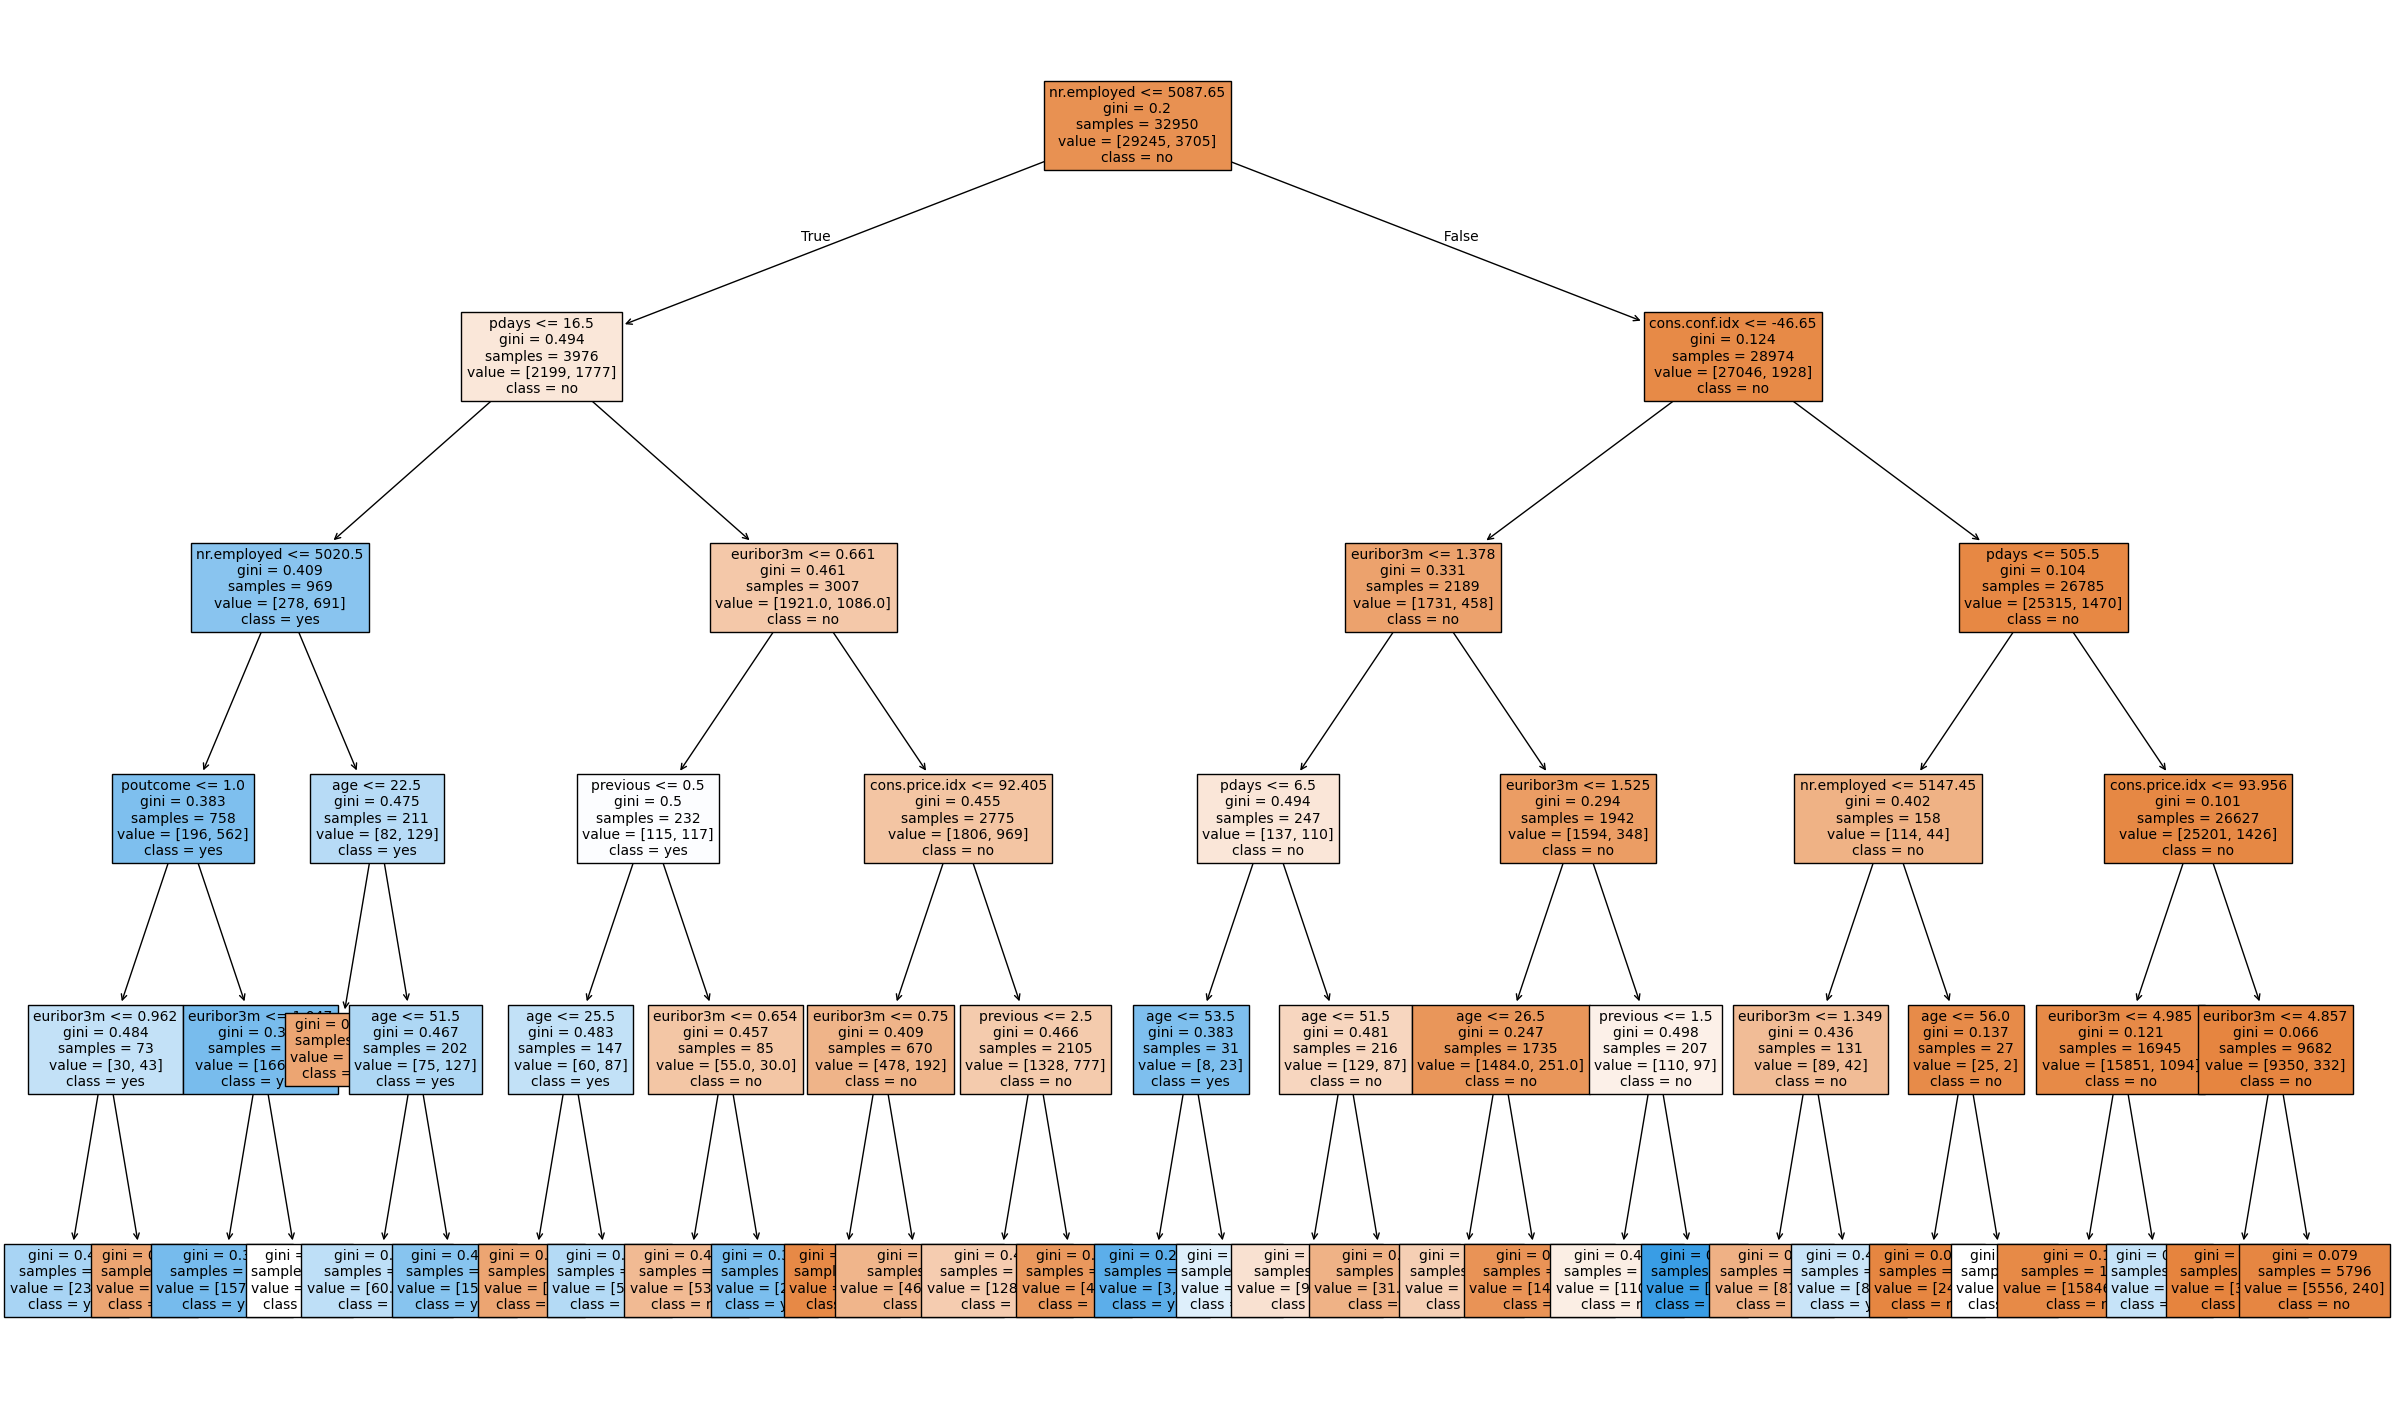

In [64]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(30, 18))
plot_tree(dt, 
          feature_names=features, 
          class_names=['no', 'yes'], 
          filled=True, 
          fontsize=10)
plt.show()